# News alerts - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

Four ways the world learns about an outbreak *before the data exists*, in order of how
easily we can use them:

- **GDELT** indexes world news in 100+ languages and gives it away through a free API with
  **no key**, which is why it is the one we scrape in class.
  **Explore:** <https://www.gdeltproject.org/>
- **HealthMap** reads news and official reports automatically and pins them on a world map.
  **Explore:** <https://www.healthmap.org/>
- **ProMED** is the opposite: real human experts posting curated outbreak reports since 1994.
  It flagged COVID about a day before the official notice. **Explore:**
  <https://promedmail.org/>
- **Media Cloud** is the scholars' media-analysis tool: **200M+ stories** in curated
  *collections* (national presses, country sets), built for studying *how* a topic is
  covered. Needs a **free API key**, so here it is a bonus rather than the main path.
  **Explore:** <https://search.mediacloud.org/>

> Open HealthMap and zoom to a region (every dot is a report), then read one ProMED post, to
> feel the difference between an automated map and a curated expert alert. Media Cloud shows
> you a third thing: attention over time, by outlet.

**The trade-off worth naming:** GDELT is *breadth with no key*; Media Cloud is *curation
with a key*. That is the same pattern as OpenSky vs OpenFlights, and Facebook posts vs the
Facebook symptom survey.


## Step 1: scan the news

> *Using the GDELT DOC 2.0 API (free, no key), find news articles from the past month*
> *that mention dengue outbreaks. Return a tidy table with date, source country, domain,*
> *headline and URL, and report how many articles and the date range.*


In [1]:
import pandas as pd, matplotlib.pyplot as plt, os, io, json
import urllib.request, urllib.parse

UA = {'User-Agent': 'SISMID2026-course/1.0 (your-email@example.com)'}

def cache_path(fname):
    for p in (f'../data/{fname}', f'data/{fname}', f'./{fname}'):
        if os.path.exists(p):
            return p
    return None

def fetch(url, timeout=120):
    return urllib.request.urlopen(urllib.request.Request(url, headers=UA), timeout=timeout).read()

# ===== EDIT for your own disease / region =====
MY_QUERY = 'dengue outbreak'
TIMESPAN = '1m'          # 1m = past month; also 1w, 3m ...
# =============================================

# --- GDELT DOC 2.0 scan (free, no key) ---
api = ('https://api.gdeltproject.org/api/v2/doc/doc'
       f'?query={urllib.parse.quote(MY_QUERY)}&mode=artlist&maxrecords=250'
       f'&format=json&timespan={TIMESPAN}')
try:
    arts = json.loads(fetch(api)).get('articles', [])
    news = pd.DataFrame([{'seendate': a.get('seendate',''),
                          'sourcecountry': a.get('sourcecountry',''),
                          'domain': a.get('domain',''),
                          'title': (a.get('title') or '').strip(),
                          'url': a.get('url','')} for a in arts])
    if news.empty: raise RuntimeError('no articles returned (rate-limited?)')
except Exception as e:
    p = cache_path('gdelt_dengue_articles.csv')
    print('Live GDELT pull failed:', e, '-> cache', p)
    news = pd.read_csv(p)

news['date'] = pd.to_datetime(news['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
print(f"{len(news)} articles, {news['date'].min()} to {news['date'].max()}")
news[['date','sourcecountry','title']].head(8)


245 articles, 2026-06-21 20:00:00 to 2026-07-21 18:00:00


,date,sourcecountry,title
0,2026-06-23 14:30:00,India,Sri Lanka to appoint military - led dengue mon...
1,2026-06-24 05:00:00,India,Why is Sri Lanka dengue outbreak straining its...
2,2026-07-16 09:15:00,Sri Lanka,Sri Lanka dengue battle at a crossroads - Brea...
3,2026-07-18 12:15:00,Sri Lanka,"Dengue deaths in 2026 top 50 , surpassing 2025..."
4,2026-07-21 08:45:00,Malaysia,Sri Lanka guna dron tentera tangani wabak denggi
5,2026-06-27 04:00:00,Sri Lanka,Sri Lanka Dengue outbreak reaches epidemic lev...
6,2026-07-06 12:45:00,United States,Diseases Impacting Bolivia and the Work To Mit...
7,2026-07-15 02:45:00,Sri Lanka,Road drains driving dengue : Study reveals 70 ...


## Step 2: emerging-outbreak watch

> *Tally the articles by source country and plot the top 12, then plot article volume*
> *per day. Summarise which countries are newly reporting activity.*

**Your check:** is a spike a real outbreak, or one wire story syndicated everywhere?


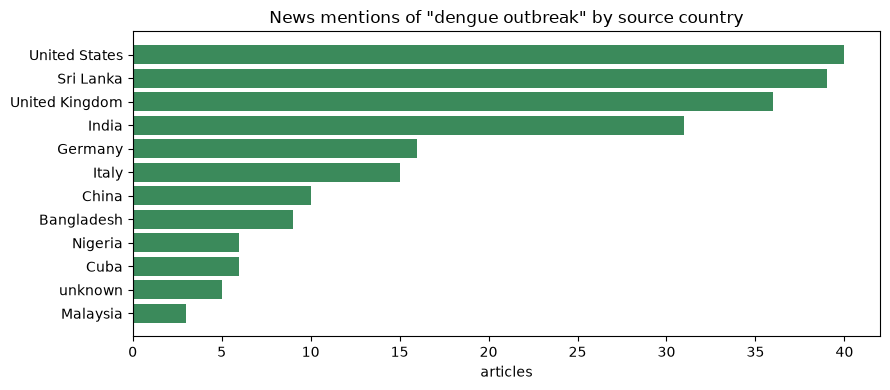

sourcecountry
United States     40
Sri Lanka         39
United Kingdom    36
India             31
Germany           16
Italy             15
China             10
Bangladesh         9
Nigeria            6
Cuba               6
unknown            5
Malaysia           3
Name: count, dtype: int64


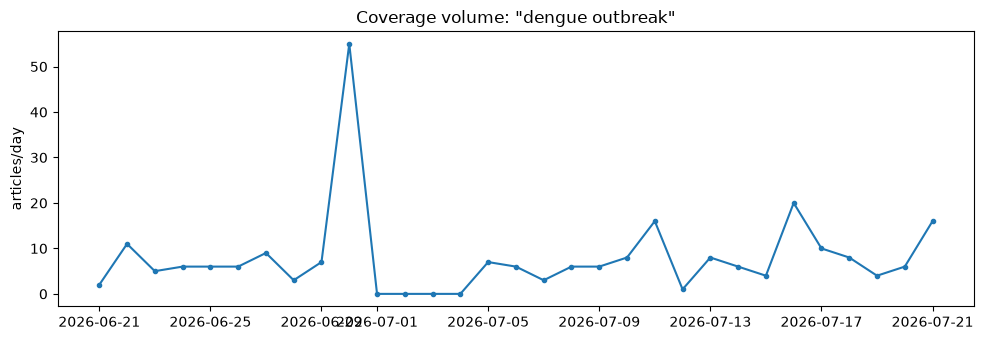

In [2]:
top = news['sourcecountry'].replace('', 'unknown').value_counts().head(12)
plt.figure(figsize=(9,4))
plt.barh(top.index[::-1], top.values[::-1], color='#3B8A5B')
plt.xlabel('articles'); plt.title(f'News mentions of "{MY_QUERY}" by source country')
plt.tight_layout(); plt.show()
print(top)

daily = news.set_index('date').resample('D').size()
plt.figure(figsize=(10,3.5))
plt.plot(daily.index, daily.values, marker='o', ms=3)
plt.ylabel('articles/day'); plt.title(f'Coverage volume: "{MY_QUERY}"')
plt.tight_layout(); plt.show()


## Step 3: sanity-check and save

> *Report article count, unique domains, and how many duplicate headlines there are*
> *(syndication). Save a tidy CSV and print the five most recent headlines.*


In [3]:
print('articles      :', len(news))
print('unique domains:', news['domain'].nunique())
print('duplicate titles:', int(news['title'].duplicated().sum()), '(syndication)')
news.to_csv('news_outbreak_watch.csv', index=False)
print('saved news_outbreak_watch.csv')
print('\nmost recent headlines:')
for _, r in news.sort_values('date', ascending=False).head(5).iterrows():
    print(' ', r['date'].date() if pd.notna(r['date']) else '?', '|', r['sourcecountry'], '|', r['title'][:90])


articles      : 245
unique domains: 175
duplicate titles: 75 (syndication)
saved news_outbreak_watch.csv

most recent headlines:
  2026-07-21 | Italy | A Castelvetro primo caso di Dengue in provincia : in corso gli interventi di disinfestazio
  2026-07-21 | India | डेंगू से निपटने के लिए श्रीलंका में ड्रोनों का प्रयोग , देखें वीडियो
  2026-07-21 | Cuba | Díaz - Canel Criticizes Trump and Rubio for Alleged Restriction of Civil Liberties in the 
  2026-07-21 | Italy | A Castelvetro primo caso di Dengue in provincia : in corso gli interventi di disinfestazio
  2026-07-21 | United Kingdom | Sri Lanka deploys military drones as worst dengue outbreak in decade kills 56 people


## Bonus: Media Cloud (needs a free API key)

> *Media Cloud indexes 200M+ news stories in curated collections and has a Python client*
> *(`pip install mediacloud`). Using mediacloud.api.SearchApi with my MEDIACLOUD_API_KEY*
> *environment variable, pull stories from the last 30 days matching my query in the US*
> *national collection (id 34412234), and show publish date, outlet and headline. If the key*
> *is not set, skip cleanly and tell me GDELT already covered it.*

Get a free key by signing up at <https://search.mediacloud.org/>. Compare what Media Cloud
returns against GDELT: curated collections versus raw breadth.


In [4]:
import os
from datetime import date, timedelta

MC_KEY = os.environ.get('MEDIACLOUD_API_KEY')
US_NATIONAL_COLLECTION = 34412234   # collection ids are listed in the Media Cloud directory

if MC_KEY:
    import mediacloud.api
    mc = mediacloud.api.SearchApi(MC_KEY)
    end = date.today(); start = end - timedelta(days=30)
    stories, _token = mc.story_list(MY_QUERY, start_date=start, end_date=end,
                                    collection_ids=[US_NATIONAL_COLLECTION])
    mc_df = pd.DataFrame(stories)
    print(f'Media Cloud: {len(mc_df)} stories on page 1 for "{MY_QUERY}"')
    if not mc_df.empty:
        cols = [c for c in ['publish_date','media_name','title'] if c in mc_df.columns]
        display(mc_df[cols].head(8))
else:
    print('MEDIACLOUD_API_KEY not set -> skipping Media Cloud.')
    print('Free key: sign up at https://search.mediacloud.org/')
    print('The GDELT results above are the no-key path and need nothing extra.')


MEDIACLOUD_API_KEY not set -> skipping Media Cloud.
Free key: sign up at https://search.mediacloud.org/
The GDELT results above are the no-key path and need nothing extra.


## Reflection

- News catches what has no data stream yet; it needs a human read.
- **Stretch:** swap in your own disease and region, and try `TIMESPAN='1w'`.
